# 👋 Welcome to the puncc multi-backend tutorial

If you already use models from PyTorch, TensorFlow, Jax or scikit learn, you can bring them to puncc without rewriting the conformal prediction method for each framework.

Puncc uses a common numerical layer so that the same conformal workflow (`fit`, `calibrate`, then `predict`) works with several tensor types and model ecosystems. In this tutorial, we will explore that design and use it in three practical examples.

**Table of contents**

- [🛠️ How the backend layer works](#backend)
- [🔥 PyTorch: conformalize a native model](#pytorch)
- [🧠 TensorFlow: use the same conformal workflow](#tensorflow)
- [🔀 PyTorch + scikit-learn: build adaptive intervals](#mixed)
- [✅ Takeaways](#takeaways)

**Useful links**

- [puncc on GitHub](https://github.com/deel-ai/puncc)
- [puncc documentation](https://deel-ai.github.io/puncc/)
- [Backend API reference](https://deel-ai.github.io/puncc/backend.html)

<a class="anchor" id="backend"></a>
## 1. 🛠️ How the backend layer works

Puncc exposes `ops` and `random` from `deel.puncc.backend`. These objects lazily provide `keras.ops` and `keras.random`, together with a few operations needed by conformal prediction, such as `weighted_quantile`, `setdiff1d`, and `where_1d`.

The lazy initialization is important: importing puncc does not immediately choose or initialize a numerical framework. You can select the backend first, and puncc will use it when the first numerical operation is evaluated.

```text
set_backend("torch")
        │
        ▼
deel.puncc.config stores the choice and sets KERAS_BACKEND
        │
        ▼  first puncc numerical operation
lazy manager imports Keras and verifies its active backend
        │
        ▼
configuration is locked; keras.ops dispatches to native tensors
```

The supported backend names are `"torch"`, `"tensorflow"`, `"jax"`, and `"numpy"`. Puncc can infer a backend from the first tensor or from an imported framework, but setting it explicitly makes the application easier to understand, especially when several frameworks are present.

### 🚩 Two rules to remember

1. Call `set_backend(...)` before importing Keras or evaluating a puncc numerical operation.
2. Once Keras initializes, the backend is locked for the lifetime of that Python process.

### ▶️ How to run this notebook

This is a **choose-an-example notebook**, so do not use **Run All** across backend sections.

For each example:

1. restart the notebook kernel;
2. jump to the example you want; and
3. run only the code cells in that example's section, from top to bottom.

Each example repeats its own imports, backend selection, data preparation, and model setup. You can therefore run it independently of the other examples.

### A minimal backend selection

Every example starts with the same pattern, changing only the backend name:

```python
from deel.puncc.config import set_backend

set_backend("torch")  # or "tensorflow", "jax", "numpy"
```

After that, the conformal method uses backend-neutral operations internally while returning tensors native to the selected backend.

<a class="anchor" id="pytorch"></a>
## 2. 🔥 PyTorch: conformalize a native model

Let us begin with a complete PyTorch workflow. We generate a heteroskedastic regression problem and define a small native PyTorch regressor. The model follows puncc's minimal predictor protocol: it is callable and provides a `fit` method, so no puncc-specific wrapper is needed.

We keep three disjoint datasets:

- the **fit set** trains the underlying predictor;
- the **calibration set** estimates the nonconformity scores; 
- the **test set** evaluates new examples.

> **To run this example:** restart the kernel, then run the next three code cells only.

In [1]:
# This cell contains every import and setup step needed by the PyTorch example.
from deel.puncc.config import get_backend, is_backend_locked, set_backend

set_backend("torch")

import torch

from deel.puncc.metrics import regression_mean_coverage, regression_sharpness
from deel.puncc.plotting import plot_prediction_intervals
from deel.puncc.regression import SplitConformalRegression

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_samples = 900
X = torch.linspace(
    -3.0, 3.0, n_samples, dtype=torch.float32, device=device
).reshape(-1, 1)
true_sigma = 0.15 + 0.35 * torch.abs(X[:, 0])
y = 1.5 + 2.0 * X[:, 0] + true_sigma * torch.randn(n_samples, device=device)

order = torch.randperm(n_samples, device=device)
fit_idx, calib_idx, test_idx = order[:450], order[450:675], order[675:]
X_fit, y_fit = X[fit_idx], y[fit_idx]
X_calib, y_calib = X[calib_idx], y[calib_idx]
X_test, y_test = X[test_idx], y[test_idx]


class TorchLinearRegressor:
    """A native PyTorch estimator with fit and call methods."""

    def __init__(self):
        self.coef_ = None

    @staticmethod
    def _design_matrix(X):
        ones = torch.ones((len(X), 1), dtype=X.dtype, device=X.device)
        return torch.cat([ones, X], dim=1)

    def fit(self, X, y):
        design = self._design_matrix(X)
        self.coef_ = torch.linalg.lstsq(design, y[:, None]).solution
        return self

    def __call__(self, X):
        if self.coef_ is None:
            raise RuntimeError("Call fit before prediction.")
        return (self._design_matrix(X) @ self.coef_).squeeze(-1)


print(f"Configured backend: {get_backend()!r}")
print(f"Device: {device}")
print(f"Fit/calibration/test sizes: {len(X_fit)}/{len(X_calib)}/{len(X_test)}")

Configured backend: 'torch'
Device: cuda
Fit/calibration/test sizes: 450/225/225


Active backend: torch (locked=True)
Prediction type: <class 'torch.Tensor'>
Empirical coverage: 0.889 (target: 0.900)
Mean interval width: 2.655


Text(0, 0.5, 'y')

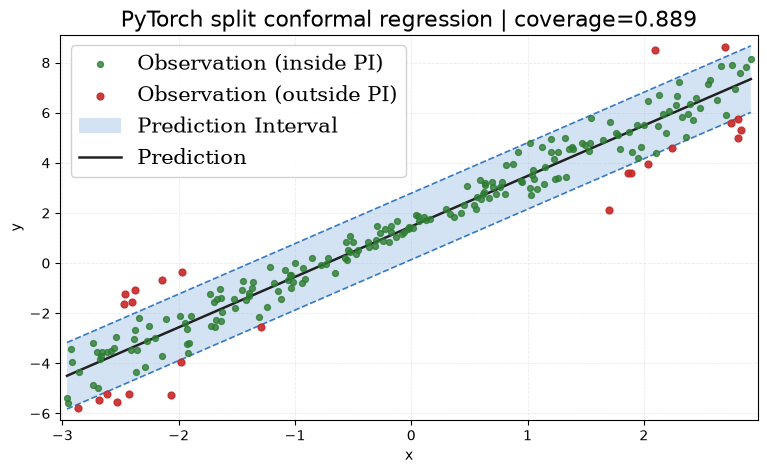

In [2]:
alpha = 0.1

# The puncc workflow is the same regardless of the selected backend.
torch_cp = SplitConformalRegression(TorchLinearRegressor())
torch_cp.fit(X_fit, y_fit)
torch_cp.calibrate(X_calib, y_calib)

y_pred, prediction_interval = torch_cp.predict(X_test, alpha=alpha)
y_lower, y_upper = prediction_interval[..., 0], prediction_interval[..., 1]

coverage = regression_mean_coverage(y_test, y_lower, y_upper)
mean_width = regression_sharpness(y_lower, y_upper).item()

print(f"Active backend: {get_backend()} (locked={is_backend_locked()})")
print(f"Prediction type: {type(y_pred)}")
print(f"Empirical coverage: {coverage:.3f} (target: {1 - alpha:.3f})")
print(f"Mean interval width: {mean_width:.3f}")

# The plotting helper expects NumPy arrays, so conversion happens only at the
# visualization boundary; conformalization above remains fully tensor-native.
ax = plot_prediction_intervals(
    X=X_test[:, 0].detach().cpu().numpy(),
    y_true=y_test.detach().cpu().numpy(),
    y_pred=y_pred.detach().cpu().numpy(),
    y_pred_lower=y_lower.detach().cpu().numpy(),
    y_pred_upper=y_upper.detach().cpu().numpy(),
    figsize=(9, 5),
    title="PyTorch split conformal regression",
)
ax.set_xlabel("x")
ax.set_ylabel("y")

In [3]:
# Once the first puncc numerical operation has run, another backend cannot
# replace the active one in this kernel.
try:
    set_backend("tensorflow")
except RuntimeError as error:
    print(type(error).__name__ + ":", error)

RuntimeError: Backend already locked. Consider calling puncc.config.set_backend() at the top of your python script.


<a class="anchor" id="tensorflow"></a>
## 3. 🧠 TensorFlow: the same conformal workflow

Now let us follow the same workflow with TensorFlow. The next cell is completely self-contained: it selects the TensorFlow backend, creates the data and Keras model, and runs `SplitConformalRegression` with the same `fit → calibrate → predict` sequence used above.

The example uses the CPU deliberately.

> **To run this example:** restart the kernel, skip the PyTorch cells, and run the next code cell only.

E0000 00:00:1791533256.258629  664059 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Active backend: tensorflow (locked=True)
Prediction type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Empirical coverage: 0.913 (target: 0.900)
Mean interval width: 7.401


Text(0, 0.5, 'y')

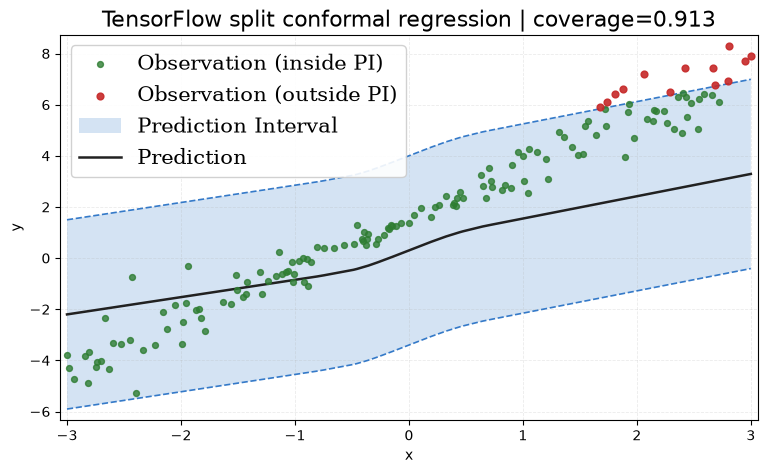

In [1]:
# This cell contains every import and setup step needed by the TensorFlow example.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from deel.puncc.config import get_backend, is_backend_locked, set_backend

set_backend("tensorflow")

import tensorflow as tf

from deel.puncc.metrics import regression_mean_coverage, regression_sharpness
from deel.puncc.plotting import plot_prediction_intervals
from deel.puncc.regression import SplitConformalRegression

tf.keras.utils.set_random_seed(7)
alpha = 0.1
n_samples = 600
X = tf.reshape(tf.linspace(-3.0, 3.0, n_samples), (-1, 1))
sigma = 0.15 + 0.35 * tf.abs(X[:, 0])
y = 1.5 + 2.0 * X[:, 0] + sigma * tf.random.normal((n_samples,))
y = tf.reshape(y, (-1, 1))

indices = tf.random.shuffle(tf.range(n_samples), seed=7)
fit_idx, calib_idx, test_idx = indices[:300], indices[300:450], indices[450:]
X_fit, y_fit = tf.gather(X, fit_idx), tf.gather(y, fit_idx)
X_calib, y_calib = tf.gather(X, calib_idx), tf.gather(y, calib_idx)
X_test, y_test = tf.gather(X, test_idx), tf.gather(y, test_idx)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1),
    ]
)
model.compile(optimizer="adam", loss="mse")

tf_cp = SplitConformalRegression(model)
tf_cp.fit(X_fit, y_fit, epochs=25, batch_size=32, verbose=0)
tf_cp.calibrate(X_calib, y_calib)

y_pred, prediction_interval = tf_cp.predict(X_test, alpha=alpha)
y_lower = prediction_interval[..., 0]
y_upper = prediction_interval[..., 1]

coverage = regression_mean_coverage(y_test, y_lower, y_upper)
mean_width = float(regression_sharpness(y_lower, y_upper))

print(f"Active backend: {get_backend()} (locked={is_backend_locked()})")
print(f"Prediction type: {type(y_pred)}")
print(f"Empirical coverage: {coverage:.3f} (target: {1 - alpha:.3f})")
print(f"Mean interval width: {mean_width:.3f}")

# Convert tensors only for visualization; the model and conformal computation
# above both use native TensorFlow tensors.
ax = plot_prediction_intervals(
    X=X_test[:, 0].numpy(),
    y_true=tf.squeeze(y_test).numpy(),
    y_pred=tf.squeeze(y_pred).numpy(),
    y_pred_lower=tf.squeeze(y_lower).numpy(),
    y_pred_upper=tf.squeeze(y_upper).numpy(),
    figsize=(9, 5),
    title="TensorFlow split conformal regression",
)
ax.set_xlabel("x")
ax.set_ylabel("y")

<a class="anchor" id="mixed"></a>
## 4. 🔀 PyTorch + scikit-learn: build locally adaptive intervals

A single computational backend does **not** mean every model must come from the same framework. This example keeps PyTorch as puncc's active numerical backend while using a scikit-learn random forest to estimate the local dispersion.

`SklearnWrapper` handles the interoperability boundary for us:

```text
PyTorch X ──► convert to NumPy ──► scikit-learn estimator
                                      │
PyTorch prediction ◄── convert back ◄─┘
```

We use a native PyTorch model for the conditional mean $\hat\mu(x)$ and a `RandomForestRegressor` for the dispersion $\hat\sigma(x)$. `LocallyAdaptiveCP` calibrates normalized residuals

$$R_i = \frac{|y_i - \hat\mu(x_i)|}{\hat\sigma(x_i) + \varepsilon},$$

then rescales the calibrated quantile at each test point. The resulting intervals can grow in noisy regions and shrink in easier ones.

Notice that we do **not** switch puncc to the NumPy backend. The backend remains PyTorch; the wrapper performs only the conversions needed by scikit-learn.

> **To run this example:** restart the kernel, skip the previous examples, and run the next two code cells only.

In [1]:
# This cell contains every import and setup step needed by the mixed example.
from deel.puncc.config import get_backend, set_backend

set_backend("torch")

import torch
from sklearn.ensemble import RandomForestRegressor

from deel.puncc.core.predictors import SklearnWrapper
from deel.puncc.metrics import regression_mean_coverage, regression_sharpness
from deel.puncc.regression import LocallyAdaptiveCP

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alpha = 0.1
n_samples = 900
X = torch.linspace(
    -3.0, 3.0, n_samples, dtype=torch.float32, device=device
).reshape(-1, 1)
true_sigma = 0.15 + 0.35 * torch.abs(X[:, 0])
y = 1.5 + 2.0 * X[:, 0] + true_sigma * torch.randn(n_samples, device=device)

order = torch.randperm(n_samples, device=device)
fit_idx, calib_idx, test_idx = order[:450], order[450:675], order[675:]
X_fit, y_fit = X[fit_idx], y[fit_idx]
X_calib, y_calib = X[calib_idx], y[calib_idx]
X_test, y_test = X[test_idx], y[test_idx]


class TorchLinearRegressor:
    """A native PyTorch estimator used for the conditional mean."""

    def __init__(self):
        self.coef_ = None

    @staticmethod
    def _design_matrix(X):
        ones = torch.ones((len(X), 1), dtype=X.dtype, device=X.device)
        return torch.cat([ones, X], dim=1)

    def fit(self, X, y):
        design = self._design_matrix(X)
        self.coef_ = torch.linalg.lstsq(design, y[:, None]).solution
        return self

    def __call__(self, X):
        if self.coef_ is None:
            raise RuntimeError("Call fit before prediction.")
        return (self._design_matrix(X) @ self.coef_).squeeze(-1)


mean_model = TorchLinearRegressor()
dispersion_model = SklearnWrapper(
    RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=8,
        random_state=7,
        n_jobs=1,
    )
)

adaptive_cp = LocallyAdaptiveCP(
    mean_model,
    dispertion_estimator=dispersion_model,
)
adaptive_cp.fit(X_fit, y_fit)
adaptive_cp.calibrate(X_calib, y_calib)

adaptive_pred, adaptive_interval = adaptive_cp.predict(X_test, alpha=alpha)
adaptive_lower = adaptive_interval[..., 0]
adaptive_upper = adaptive_interval[..., 1]
sigma_pred = dispersion_model(X_test)

adaptive_coverage = regression_mean_coverage(
    y_test,
    adaptive_lower,
    adaptive_upper,
)
adaptive_width = regression_sharpness(
    adaptive_lower,
    adaptive_upper,
).item()

print(f"Active puncc backend: {get_backend()}")
print(f"Mean-model output: {type(adaptive_pred)}")
print(f"Wrapped forest output: {type(sigma_pred)}")
print(f"Underlying estimator: {type(dispersion_model.model)}")
print(f"Empirical coverage: {adaptive_coverage:.3f} (target: {1 - alpha:.3f})")
print(f"Mean interval width: {adaptive_width:.3f}")

Active puncc backend: torch
Mean-model output: <class 'torch.Tensor'>
Wrapped forest output: <class 'torch.Tensor'>
Underlying estimator: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Empirical coverage: 0.916 (target: 0.900)
Mean interval width: 2.573


Text(0, 0.5, 'y')

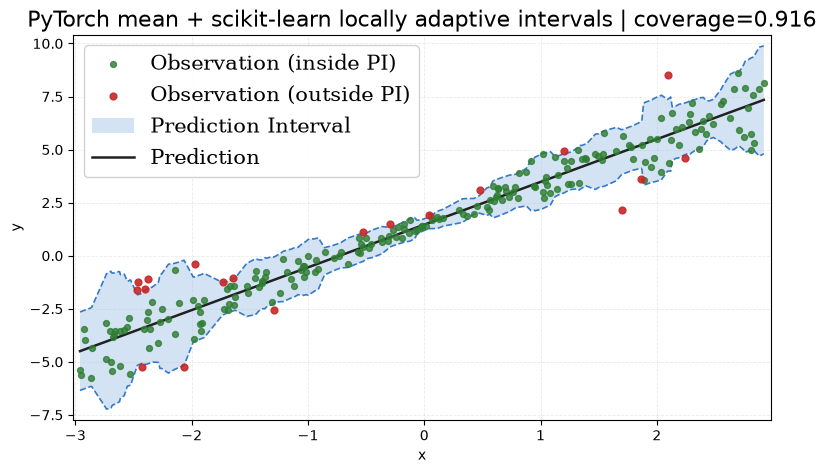

In [2]:
from deel.puncc.plotting import plot_prediction_intervals

# SklearnWrapper has already returned the forest predictions to the PyTorch
# backend. Convert the final tensors to NumPy only for plotting.
ax = plot_prediction_intervals(
    X=X_test[:, 0].detach().cpu().numpy(),
    y_true=y_test.detach().cpu().numpy(),
    y_pred=adaptive_pred.detach().cpu().numpy(),
    y_pred_lower=adaptive_lower.detach().cpu().numpy(),
    y_pred_upper=adaptive_upper.detach().cpu().numpy(),
    figsize=(9, 5),
    title="PyTorch mean + scikit-learn locally adaptive intervals",
)
ax.set_xlabel("x")
ax.set_ylabel("y")

<a class="anchor" id="takeaways"></a>
## 5. ✅ Takeaways

You have now seen the same puncc conformal workflow applied across two deep-learning frameworks and one mixed-framework pipeline.

- Puncc's conformal algorithms use one lazy numerical interface instead of framework-specific implementations.
- Explicitly selecting the backend makes framework behavior predictable.
- A backend is locked after initialization, so restart the kernel before choosing a different one.
- `fit`, `calibrate`, and `predict` remain the same across PyTorch and TensorFlow, while outputs stay native to the selected backend.
- `SklearnWrapper` lets a NumPy/scikit-learn estimator participate in a tensor-native workflow without manual conversions in your conformal code.

From here, you can replace the small demonstration models with your own predictors while keeping the conformalization steps unchanged. Happy conformalizing! 🎉